<a href="https://colab.research.google.com/github/fabricejumel/5IRC-2026-2027-CYBER-SIA/blob/main/Attaques_yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q ultralytics
import torch
import torchvision
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Utilisation du périphérique :", device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 4.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Utilisation du périphérique : cuda


In [4]:
import glob
from ultralytics.utils.downloads import download

# Téléchargement du jeu de données d'exemple COCO8
download("https://ultralytics.com/assets/coco8.zip", dir="./datasets")

# Recherche large de toutes les images disponibles dans le dossier
image_paths = sorted(glob.glob("./datasets/coco8/**/*.jpg", recursive=True))

# Si on en a moins de 8, on duplique la liste pour atteindre exactement 8 entrées de test
if len(image_paths) < 8:
    image_paths = (image_paths * ((8 // len(image_paths)) + 1))[:8]
else:
    image_paths = image_paths[:8]

print(f"✅ {len(image_paths)} images prêtes pour le test.")

WARNING ⚠️ Skipping datasets/coco8.zip unzip as destination path /content/datasets/coco8 already exists.
✅ 8 images prêtes pour le test.


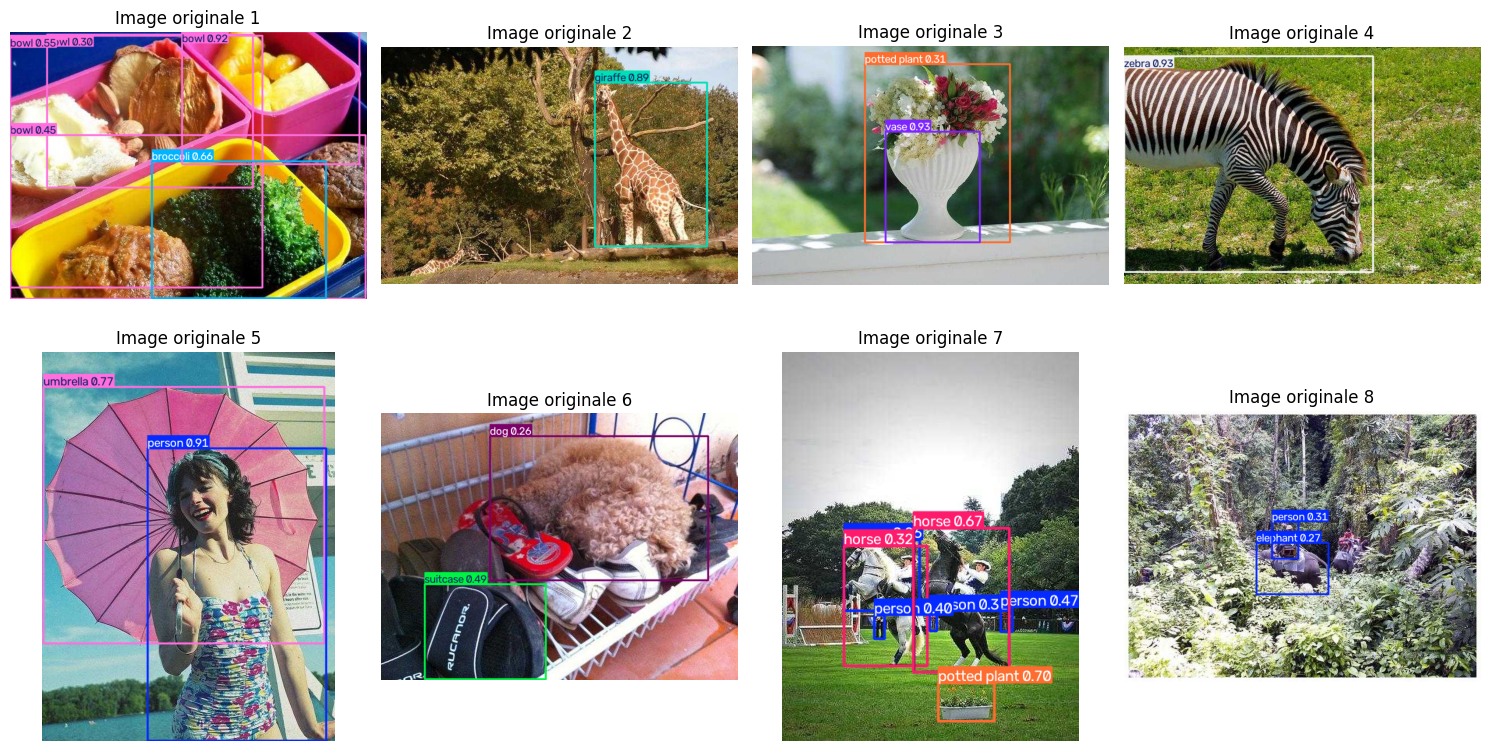

In [5]:
# Chargement du modèle YOLOv8 nano en mode entraînement (nécessaire pour les gradients)
model = YOLO("yolov8n.pt").to(device)
model.model.train()

# Affichage initial des 8 images
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for idx, img_path in enumerate(image_paths):
    results = model(img_path, verbose=False)[0]
    res_plotted = results.plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    axes[idx].imshow(res_rgb)
    axes[idx].axis("off")
    axes[idx].set_title(f"Image originale {idx+1}")

plt.tight_layout()
plt.show()